#Project :Chemical segergration

In [21]:
import pandas as pd

In [22]:
X_train = pd.read_csv('Logistic_X_Train.csv')
y_train = pd.read_csv('Logistic_Y_Train.csv')

### X_train (Features) Data Overview

In [23]:
display(X_train.head())

,f1,f2,f3
0,-1.239375,0.749101,-0.528515
1,-1.036070,0.801436,-1.283712
2,-0.615579,1.579521,-1.391927
3,1.335978,1.348651,1.433564
4,0.658925,1.300019,0.571603


#### X_train Shape

In [24]:
print(X_train.shape)

(3000, 3)


#### X_train Data Types

In [25]:
print(X_train.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      3000 non-null   float64
 1   f2      3000 non-null   float64
 2   f3      3000 non-null   float64
dtypes: float64(3)
memory usage: 70.4 KB
None


#### X_train Missing Values

In [26]:
print(X_train.isnull().sum())

f1    0
f2    0
f3    0
dtype: int64


### y_train (Target) Data Overview

In [27]:
display(y_train.head())

,label
0,1
1,1
2,1
3,0
4,0


#### y_train Shape

In [28]:
print(y_train.shape)

(3000, 1)


#### y_train Data Types

In [29]:
print(y_train.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   3000 non-null   int64
dtypes: int64(1)
memory usage: 23.6 KB
None


#### y_train Missing Values

In [30]:
print(y_train.isnull().sum())

label    0
dtype: int64


#### y_train Class Distribution

In [31]:
print(y_train['label'].value_counts())

label
0    1509
1    1491
Name: count, dtype: int64


In [32]:
print(y_train['label'].value_counts(normalize=True))

label
0    0.503
1    0.497
Name: proportion, dtype: float64


### Data Visualization and Statistical Analysis

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Create directory for plots if it doesn't exist
plots_dir = 'results/plots'
os.makedirs(plots_dir, exist_ok=True)

# Combine X_train and y_train for easier plotting
df_combined = X_train.copy()
df_combined['label'] = y_train['label']

print(f"Plots will be saved to: {os.path.abspath(plots_dir)}")

Plots will be saved to: c:\Users\Rounak choudhary\OneDrive\Desktop\PRML_course_project-\PRML_course_project-\results\plots


#### Class Distribution Countplot

C:\Users\Rounak choudhary\AppData\Local\Temp\ipykernel_18388\2806589578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_combined, palette='viridis')


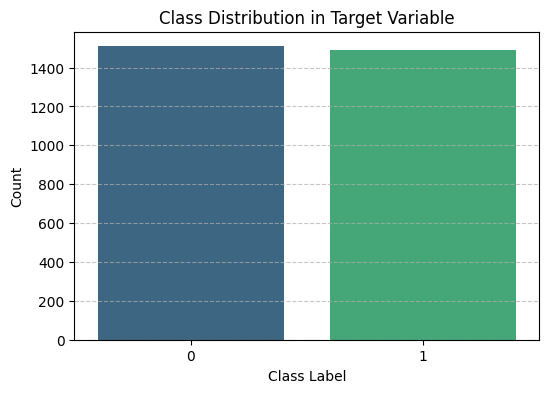

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df_combined, palette='viridis')
plt.title('Class Distribution in Target Variable')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(plots_dir, 'class_distribution_countplot.png'))
plt.show()

The class distribution countplot shows the number of instances for each class label. As previously noted, the dataset exhibits a balanced class distribution, with class 0 having 1509 instances and class 1 having 1491 instances. This nearly equal distribution suggests that class imbalance is not a significant concern for this dataset, which is beneficial for model training as it prevents bias towards the majority class.

#### Correlation Heatmap

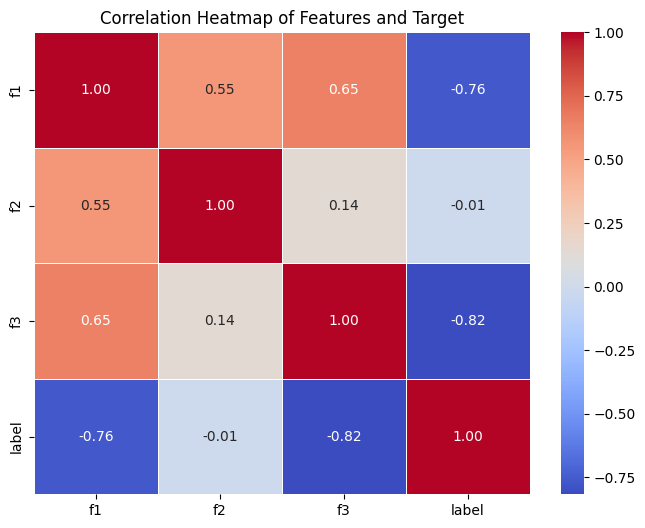

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_combined.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Features and Target')
plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.png'))
plt.show()

The correlation heatmap visualizes the Pearson correlation coefficients between all pairs of features and the target variable. Strong positive or negative correlations  indicate a linear relationship, while values close to 0 suggest no linear correlation. Observing the correlations between features and the 'label' can provide initial insights into which features might be more predictive of the target class. High correlations between features can be identified

#### Pairplot

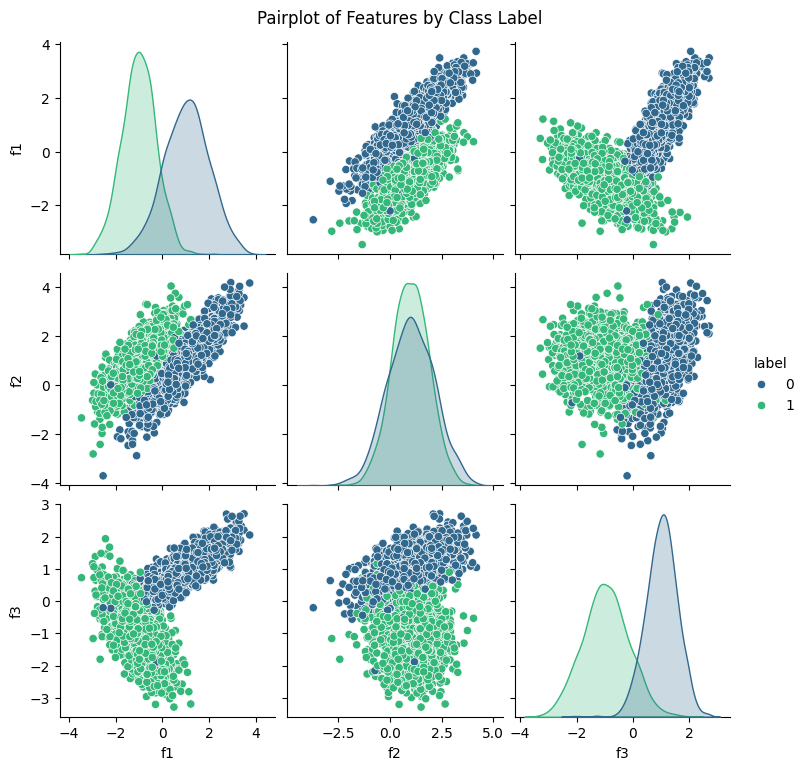

In [36]:
sns.pairplot(df_combined, hue='label', diag_kind='kde', palette='viridis')
plt.suptitle('Pairplot of Features by Class Label', y=1.02) # Adjust suptitle position
plt.savefig(os.path.join(plots_dir, 'pairplot.png'))
plt.show()

The pairplot provides a matrix of scatter plots for each feature pair, along with kernel density estimates (KDEs) for individual features, colored by the class label. This visualization is crucial for understanding:
-   **Feature Separability:** How well the different classes are separated in 2D projection for each pair of features. Overlapping distributions suggest less separability.
-   **Possible Correlations:** Visual patterns in scatter plots (e.g., linear trends) indicate potential correlations between feature pairs.
-   **Linear Separability:** If the classes can be distinctly separated by a straight line or plane in any of the 2D scatter plots, it suggests the dataset might be linearly separable to some extent. Distinct clusters for each class indicate good separability. If classes are highly intertwined across all feature pairs, linear separability is unlikely.

#### 3D Scatter Plot of Features Colored by Label

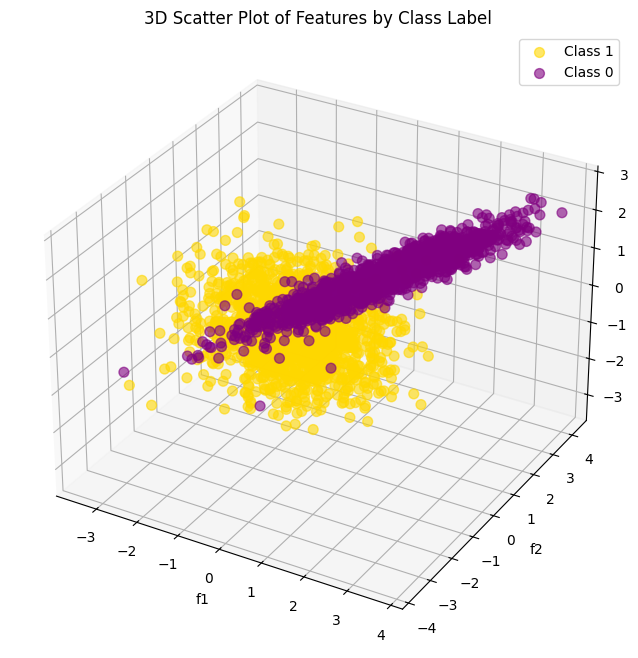

In [37]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define colors for the two classes
colors = ['purple', 'gold']

# Plot each class separately to assign different colors
for label_val in df_combined['label'].unique():
    subset = df_combined[df_combined['label'] == label_val]
    ax.scatter(subset['f1'], subset['f2'], subset['f3'],
               label=f'Class {label_val}',
               color=colors[label_val],  # Assign color based on label index
               alpha=0.6, s=50)

ax.set_xlabel('f1')
ax.set_ylabel('f2')
ax.set_zlabel('f3')
ax.set_title('3D Scatter Plot of Features by Class Label')
ax.legend()
plt.savefig(os.path.join(plots_dir, '3d_scatter_plot.png'))
plt.show()

The 3D scatter plot visualizes the three features (`f1`, `f2`, `f3`) simultaneously, with data points colored according to their class label. This plot helps to assess:
-   **Feature Separability in 3D:** It provides a spatial understanding of how well the classes are separated when all three features are considered together. Distinct clusters for each class in 3D space indicate good separability.
-   **Linear Separability:** If a plane can be drawn to cleanly divide the two classes in this 3D space, the dataset is linearly separable. Intertwined or overlapping distributions in 3D suggest that linear models might struggle to achieve high accuracy.

#### Boxplots for Each Feature Grouped by Class

C:\Users\Rounak choudhary\AppData\Local\Temp\ipykernel_18388\2970155809.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_combined, palette='viridis')
C:\Users\Rounak choudhary\AppData\Local\Temp\ipykernel_18388\2970155809.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_combined, palette='viridis')


C:\Users\Rounak choudhary\AppData\Local\Temp\ipykernel_18388\2970155809.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_combined, palette='viridis')


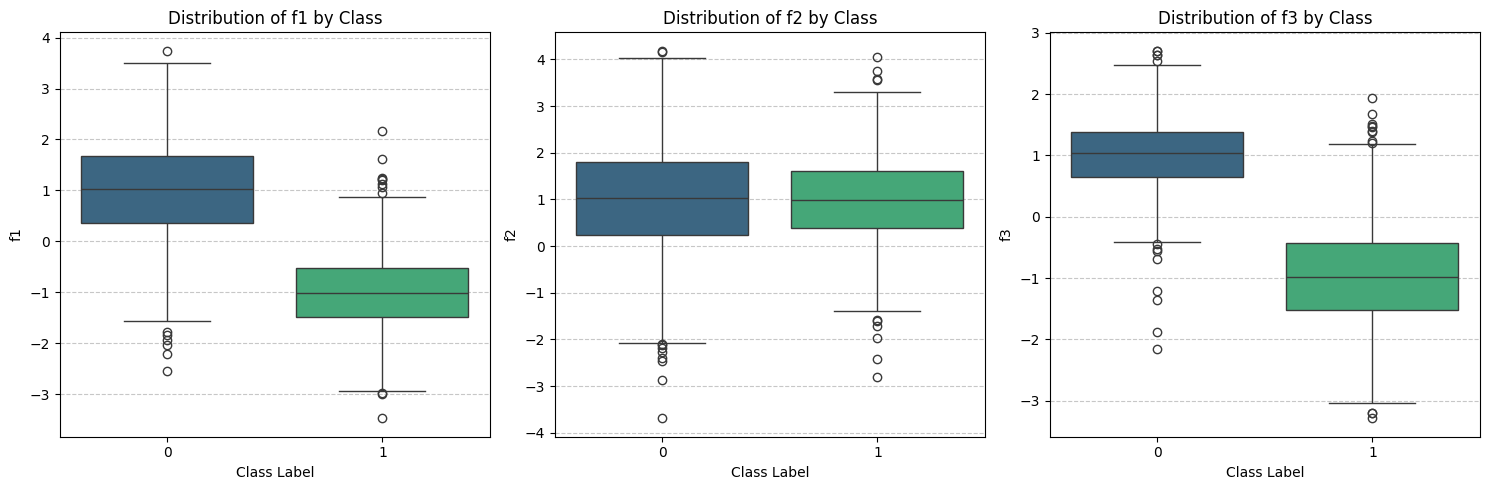

In [38]:
feature_names = ['f1', 'f2', 'f3']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(feature_names):
    plt.subplot(1, len(feature_names), i + 1)
    sns.boxplot(x='label', y=feature, data=df_combined, palette='viridis')
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel('Class Label')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'feature_boxplots_by_class.png'))
plt.show()

These boxplots illustrate the distribution of each individual feature (`f1`, `f2`, `f3`) for each class label. They are useful for understanding:
-   **Feature Separability:** If the median values and interquartile ranges (IQRs) of a feature are significantly different between the classes, that feature contributes to separating the classes
-   **Class Imbalance Presence:** While not directly showing imbalance (as the plot is by feature distribution), it implicitly confirms the distinctness of classes based on feature values. The consistent spread across classes (or lack thereof) provides visual clues about the feature's utility in classification. Features with clear separation in their boxplots across classes are strong candidates for classification.

#### Statistical Analysis: Mean, Variance, Feature Ranges, and Class Balance Ratio

In [39]:
print('--- Statistical Summary of Features by Class ---\n')
for feature in feature_names:
    print(f'Feature: {feature}')
    print(df_combined.groupby('label')[feature].agg(['mean', 'var', lambda x: x.max() - x.min()]).rename(columns={'<lambda>': 'range'}))
    print('\n')

print('\n--- Overall Class Balance Ratio ---\n')
class_balance_ratio = df_combined['label'].value_counts(normalize=True)
print(class_balance_ratio)

--- Statistical Summary of Features by Class ---

Feature: f1
           mean       var  <lambda_0>
label                                
0      1.020165  0.940650    6.286426
1     -1.017484  0.540666    5.642888


Feature: f2
           mean       var  <lambda_0>
label                                
0      1.012199  1.290542    7.877630
1      0.986218  0.803445    6.845284


Feature: f3
           mean       var  <lambda_0>
label                                
0      1.011746  0.312784    4.862034
1     -0.964630  0.662087    5.219873



--- Overall Class Balance Ratio ---

label
0    0.503
1    0.497
Name: proportion, dtype: float64


This section provides a quantitative statistical summary:
-   **Mean and Variance:** Comparing the mean and variance of each feature across different classes gives insights into how the central tendency and spread of feature values differ for each class
-   **Feature Ranges:** The range (max - min) for each feature, broken down by class, provides an understanding of the span of values for that feature within each class.
-   **Class Balance Ratio:** Reconfirming the class balance ratio numerically demonstrates the proportion of each class in the dataset. As observed, the ratio is close to 0.5 for both classes, indicating a well-balanced dataset. This statistical confirmation supports the visual findings from the countplot and reinforces that class imbalance.

# Preprocessing Pipeline

## Data Loading and Preparation

Load the chemical segregation dataset and prepare it for preprocessing.

In [ ]:
# Load dataset for preprocessing
x_data_path = 'Logistic_X_Train.csv'
y_data_path = 'Logistic_Y_Train.csv'
features = pd.read_csv(x_data_path)
labels = pd.read_csv(y_data_path).squeeze('columns')
df = features.copy()
df['label'] = labels
print(f"Dataset loaded successfully from {x_data_path} and {y_data_path}")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Separate features and labels
features = df.drop('label', axis=1)
labels = df['label']

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Class distribution: {labels.value_counts().to_dict()}")

In [ ]:
## Stratified Train-Test Split
Reasoning:
- Stratified splitting ensures equal class proportions in training and testing sets
- Prevents class imbalance issues that could bias model evaluation
- Critical for reliable model evaluation and preventing biased performance metrics

In [ ]:
# Perform stratified train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(" STRATIFIED TRAIN-TEST SPLIT ")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training class distribution: {y_train.value_counts().to_dict()}")
print(f"Test class distribution: {y_test.value_counts().to_dict()}")

In [ ]:
## Standard Scaling

Reasoning:
- Required for SVM, Logistic Regression and KNN because these models depend on feature magnitude and distance geometry
- Standard scaling centers features at mean=0, std=1
- Prevents features with larger magnitudes from dominating the learning process

In [ ]:
# Apply StandardScaler
from sklearn.preprocessing import StandardScaler
import joblib
from pathlib import Path

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(" STANDARD SCALING APPLIED ")
print(f"Training data - Mean: {X_train_scaled.mean().round(4).tolist()}")
print(f"Training data - Std: {X_train_scaled.std().round(4).tolist()}")

# Save scaled datasets
processed_dir = Path('../processed_data')
processed_dir.mkdir(exist_ok=True)

X_train_scaled.to_csv(processed_dir / 'X_train_scaled.csv', index=False)
X_test_scaled.to_csv(processed_dir / 'X_test_scaled.csv', index=False)

# Save scaler
joblib.dump(scaler, processed_dir / 'scaler.pkl')

print(f"Scaled datasets saved to {processed_dir}")
print(f"Scaler saved to {processed_dir / 'scaler.pkl'}")

In [ ]:
## PCA Analysis
Reasoning:
- PCA identifies directions of maximum variance in the data
- Reveals dimensional redundancy and variance concentration across features
- Enables understanding of data structure and potential dimensionality reduction

In [ ]:
# Apply PCA
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(" PCA ANALYSIS ")
print(f"Number of components: {pca.n_components_}")
print("Explained variance ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {ratio:.4f}")

# Plot variance contribution
plt.figure(figsize=(10, 6))
components = range(1, len(pca.explained_variance_ratio_) + 1)
plt.bar(components, pca.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.plot(components, np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA: Variance Contribution by Component')
plt.legend()
plt.grid(True, alpha=0.3)

# Save plot
plt.savefig(processed_dir / 'pca_variance_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Save PCA transformed datasets
pd.DataFrame(X_train_pca).to_csv(processed_dir / 'X_train_pca.csv', index=False)
pd.DataFrame(X_test_pca).to_csv(processed_dir / 'X_test_pca.csv', index=False)

print(f"PCA transformed datasets saved to {processed_dir}")

In [ ]:
## LDA Analysis

Reasoning:
- LDA maximizes between-class scatter while minimizing within-class scatter
- Supervised approach that considers class labels for optimal separation
- Particularly effective for classification with known class structure

In [ ]:
# Apply LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

n_classes = len(np.unique(y_train))
n_features = X_train_scaled.shape[1]
n_components = min(n_classes - 1, n_features)

lda = LDA(n_components=n_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print(" LDA ANALYSIS ")
print(f"Number of components: {lda.n_components}")
print(f"Classes: {n_classes}")
print(f"Explained variance ratio: {lda.explained_variance_ratio_}")

# Class means in original space
print("Class means in feature space:")
for i, mean in enumerate(lda.means_):
    print(f"  Class {i}: {mean}")

# Save LDA transformed datasets
pd.DataFrame(X_train_lda).to_csv(processed_dir / 'X_train_lda.csv', index=False)
pd.DataFrame(X_test_lda).to_csv(processed_dir / 'X_test_lda.csv', index=False)

print(f"LDA transformed datasets saved to {processed_dir}")
print("\nPreprocessing pipeline completed successfully!")